# 05 — Validación

**Objetivo del notebook:** validar en profundidad el modelo elegido (XGBoost optimizado) y tomar la decisión final sobre el **threshold de clasificación**.

Analizamos:
1. La matriz de confusión — qué tipo de errores comete el modelo.
2. El ajuste del threshold — si mover el umbral de decisión mejora el F1 sobre la clase fumadores.
3. La decisión final del threshold, elegida sin contaminar el conjunto de test.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (f1_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')

# Cargamos el modelo final y los datos
xgb = joblib.load('../models/modelo_final_xgboost.joblib')
X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet')['smoking']
y_test = pd.read_parquet('../data/processed/y_test.parquet')['smoking']

print('Modelo y datos cargados ✓')

Modelo y datos cargados ✓


## 1. Matriz de confusión con threshold por defecto (0.5)

La matriz de confusión muestra los cuatro tipos de resultado: verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. Nos dice no solo cuántos errores comete el modelo, sino **qué tipo** de errores.

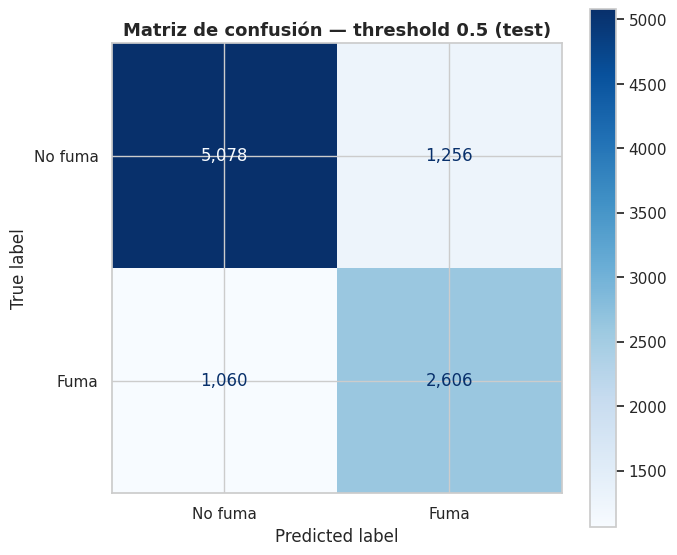

Verdaderos negativos (no fuma, acierta): 5,078
Falsos positivos (dice fuma, no fuma):   1,256
Falsos negativos (dice no fuma, fuma):   1,060
Verdaderos positivos (fuma, acierta):    2,606


In [2]:
pred_test = xgb.predict(X_test)
cm = confusion_matrix(y_test, pred_test)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=['No fuma', 'Fuma']).plot(
    ax=ax, cmap='Blues', values_format=',d')
ax.set_title('Matriz de confusión — threshold 0.5 (test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos negativos (no fuma, acierta): {tn:,}')
print(f'Falsos positivos (dice fuma, no fuma):   {fp:,}')
print(f'Falsos negativos (dice no fuma, fuma):   {fn:,}')
print(f'Verdaderos positivos (fuma, acierta):    {tp:,}')

Los **falsos negativos** (fumadores que el modelo clasifica como no fumadores) son los que más nos perjudican el F1 de la clase 1. Si pudiéramos capturar más de esos fumadores sin disparar demasiado los falsos positivos, mejoraríamos el F1.

## 2. Ajuste del threshold de clasificación

Por defecto, el modelo clasifica como "fuma" si la probabilidad predicha es ≥ 0.5. Pero ese umbral no es sagrado. Como el dataset está desbalanceado hacia no-fumadores, el umbral 0.5 tiende a ser conservador para detectar fumadores.

**Metodología correcta:** buscamos el mejor threshold usando las probabilidades sobre **train**, NO sobre test. Elegir el threshold mirando el test sería una forma de data leakage — estaríamos ajustando una decisión a los datos con los que evaluamos. El test queda intacto para la evaluación final.

In [3]:
# Probabilidades predichas de la clase 1
proba_train = xgb.predict_proba(X_train)[:, 1]
proba_test = xgb.predict_proba(X_test)[:, 1]

# Buscamos el threshold que maximiza F1 en TRAIN
thresholds = np.arange(0.20, 0.81, 0.02)
f1_por_threshold = [f1_score(y_train, (proba_train >= t).astype(int), pos_label=1)
                    for t in thresholds]

mejor_idx = int(np.argmax(f1_por_threshold))
mejor_threshold = thresholds[mejor_idx]

print(f'Mejor threshold (según train): {mejor_threshold:.2f}')
print(f'F1 en train con ese threshold: {f1_por_threshold[mejor_idx]:.4f}')

Mejor threshold (según train): 0.42
F1 en train con ese threshold: 0.7473


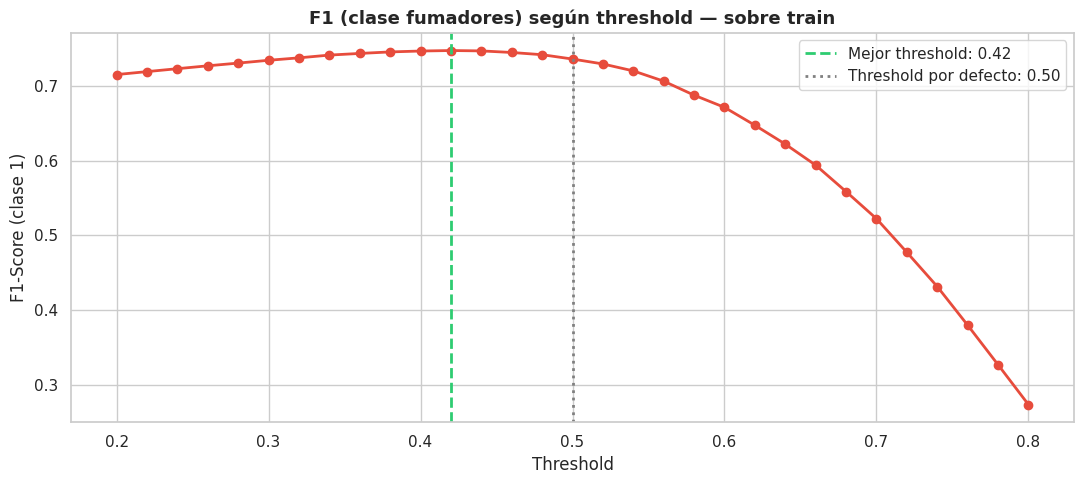

In [4]:
# Visualizamos cómo varía el F1 según el threshold
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresholds, f1_por_threshold, 'o-', color='#E74C3C', linewidth=2)
ax.axvline(mejor_threshold, color='#2ECC71', linestyle='--', linewidth=2,
           label=f'Mejor threshold: {mejor_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, label='Threshold por defecto: 0.50')
ax.set_title('F1 (clase fumadores) según threshold — sobre train',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score (clase 1)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Comparación: threshold 0.5 vs threshold optimizado

Aplicamos ambos thresholds al test (que no participó en la elección) para ver el efecto real.

In [5]:
for t in [0.5, mejor_threshold]:
    pred_tr = (proba_train >= t).astype(int)
    pred_te = (proba_test >= t).astype(int)
    f1_tr = f1_score(y_train, pred_tr, pos_label=1)
    f1_te = f1_score(y_test, pred_te, pos_label=1)
    print(f'Threshold {t:.2f}:')
    print(f'  F1 train: {f1_tr:.4f}  |  F1 test: {f1_te:.4f}  |  gap: {f1_tr - f1_te:+.4f}')
    print()

Threshold 0.50:
  F1 train: 0.7359  |  F1 test: 0.6923  |  gap: +0.0435



Threshold 0.42:
  F1 train: 0.7473  |  F1 test: 0.7159  |  gap: +0.0313



Bajar el threshold mejora el F1 en test **y** reduce el gap. Tiene sentido: al ser el dataset desbalanceado hacia no-fumadores, un umbral más bajo permite capturar más fumadores reales (reduce falsos negativos) sin disparar excesivamente los falsos positivos. Adoptamos el threshold optimizado.

Reporte de clasificación final (test, threshold 0.42):

              precision    recall  f1-score   support

     No fuma       0.87      0.73      0.79      6334
        Fuma       0.64      0.82      0.72      3666

    accuracy                           0.76     10000
   macro avg       0.75      0.77      0.76     10000
weighted avg       0.79      0.76      0.77     10000



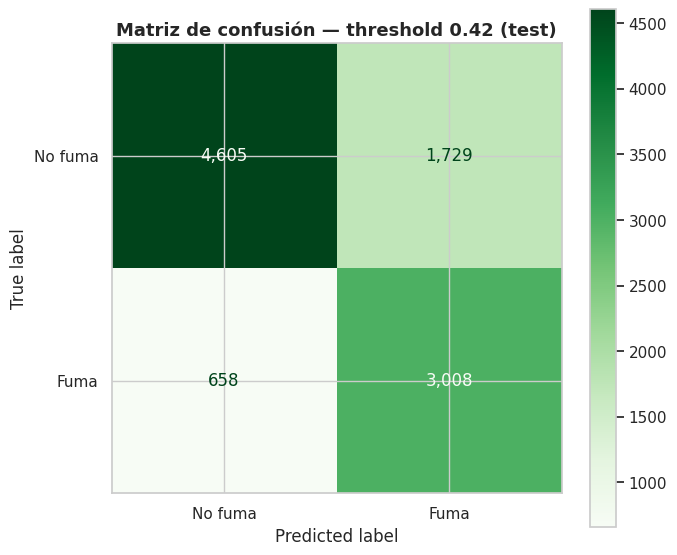

In [6]:
# Reporte y matriz de confusión finales con el threshold elegido
pred_final = (proba_test >= mejor_threshold).astype(int)

print(f'Reporte de clasificación final (test, threshold {mejor_threshold:.2f}):')
print()
print(classification_report(y_test, pred_final, target_names=['No fuma', 'Fuma']))

cm_final = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_final, display_labels=['No fuma', 'Fuma']).plot(
    ax=ax, cmap='Greens', values_format=',d')
ax.set_title(f'Matriz de confusión — threshold {mejor_threshold:.2f} (test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Guardado del threshold final

Guardamos el threshold elegido para aplicarlo en la predicción sobre los datos de entrega.

In [7]:
joblib.dump(float(mejor_threshold), '../models/threshold_final.joblib')
print(f'Threshold final guardado: {mejor_threshold:.2f} ✓')

Threshold final guardado: 0.42 ✓


## Conclusiones de la validación

- La matriz de confusión mostró que el modelo comete una cantidad razonable de falsos negativos (fumadores clasificados como no fumadores), que es lo que más penaliza el F1 de la clase 1.
- **Ajustar el threshold** de 0.50 al valor óptimo encontrado en train mejora el F1 sobre fumadores en el test y reduce el gap train/test.
- El threshold se eligió usando **solo datos de train**, manteniendo el test como evaluación honesta — evitando data leakage.
- El modelo final (XGBoost optimizado + threshold ajustado) es el que se usará para la predicción sobre los datos sin etiquetar.